In [2]:
import numpy as np
from numpy import pi
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from collections import defaultdict
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.circuit.library import MCXGate
from qiskit.circuit.library import UnitaryGate, QFT, QFTGate
import matplotlib.pyplot as plt
import math

In [3]:
def q_simulation(qc,shots=1000,return_count=False) :
    simulator = Aer.get_backend('aer_simulator')

    # 회로 컴파일
    compiled_circuit = transpile(qc, simulator)

    # 실행
    job = simulator.run(compiled_circuit, shots=shots)
    result = job.result()

    # 결과 확인
    counts = result.get_counts()

    # 시각화 위해서 앞 뒤 순서 바꾸기
    new_keys = []
    for i in counts.keys():
        new_keys.append( i[::-1] )

    counts_reversed = dict( zip(new_keys,counts.values()) )

    if return_count == True :
        return counts_reversed
    # 히스토그램 시각화
    return plot_histogram(counts_reversed)

# 1. QFT (Quantum Fourier Transform)

## 핵심 아이디어: 숫자를 "회전"으로 바꿔 적기

QFT는 큐비트에 담긴 숫자를 큐비트들의 **회전(위상)** 으로 바꿔 적는 변환입니다. 입력으로 정수 $x$ 가 들어오면, QFT는 그 숫자를 각 큐비트의 회전 각도에 나눠 새깁니다. 입력 숫자가 클수록 더 많이 회전합니다.

조금 더 정확히는, $n$ 큐비트 QFT가 기저 상태 $|x\rangle$ 을 다음처럼 바꿉니다.

$$
\text{QFT}\,|x\rangle = \frac{1}{\sqrt{2^n}}\sum_{k=0}^{2^n-1} e^{2\pi i \, x k / 2^n}\,|k\rangle
$$

복잡해 보이지만 핵심은 지수 안의 $e^{2\pi i \, x k / 2^n}$, 즉 "$x$ 에 비례하는 위상(회전)"입니다. 아래 예제에서는 이 회전을 Bloch sphere로 눈으로 확인합니다.

QFT 자체도 중요하지만, 바로 다음에 배울 **QPE** 에서 이 변환의 역(inverse QFT)을 써서 위상을 거꾸로 "읽어내는" 데 쓰입니다. 그래서 먼저 감을 잡아둡니다.

## 2 큐비트 예제

2 큐비트로는 정수 0, 1, 2, 3 ($|00\rangle, |01\rangle, |10\rangle, |11\rangle$)을 표현할 수 있습니다. 아래에서는 이 네 입력 각각에 QFT를 적용한 뒤 Bloch sphere로 결과를 봅니다.

**무엇을 관찰하면 되는가:** QFT를 거치면 각 큐비트는 적도(equator) 위에 놓이고, 입력 숫자가 1씩 커질수록 정해진 각도만큼 더 회전합니다. 즉 입력 숫자가 큐비트들의 회전 각도로 "인코딩"되는 것을 직접 볼 수 있습니다.

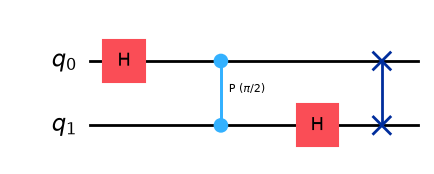

In [4]:
qc = QuantumCircuit(2)

# 첫 번째 큐비트 (q0) 처리
qc.h(0)
qc.cp(pi/2, 1, 0) # Control: q1, Target: q0

# 두 번째 큐비트 (q1) 처리
qc.h(1)

# 마지막에 Swap (q0와 q2 교환)
qc.swap(0, 1)
qc.draw('mpl')

In [5]:
# 하나의 블록으로 저장하는 코드

qc_2 = QuantumCircuit(2, name='QFT_2')

# 첫 번째 큐비트 (q0) 처리
qc_2.h(0)
qc_2.cp(pi/2, 1, 0) # Control: q1, Target: q0

# 두 번째 큐비트 (q1) 처리
qc_2.h(1)

# 마지막에 Swap (q0와 q2 교환)
qc_2.swap(0, 1)

qft_2_gate=qc_2.to_gate()

### 입력 0 : $|00\rangle$

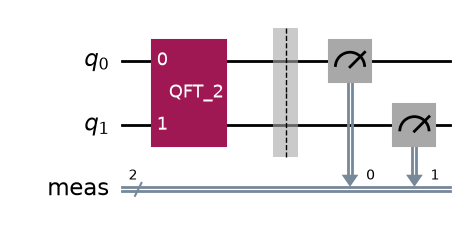

In [6]:
qc= QuantumCircuit(2)
qc.append(qft_2_gate, [0, 1])
state = Statevector(qc)
qc.measure_all()
qc.draw('mpl')

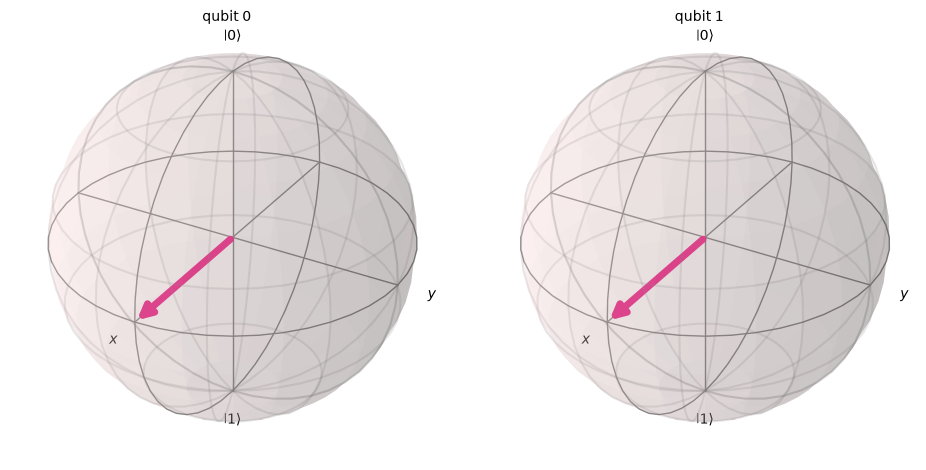

In [7]:
plot_bloch_multivector(state)

### 입력 1 : $|01\rangle$

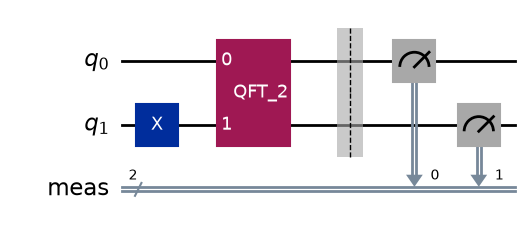

In [8]:
qc= QuantumCircuit(2)
qc.x(1)
qc.append(qft_2_gate, [0, 1])
state = Statevector(qc)
qc.measure_all()
qc.draw('mpl')

In [ ]:
plot_bloch_multivector(state)

### 입력 2 : $|10\rangle$

In [ ]:
qc= QuantumCircuit(2)
qc.x(0)
qc.append(qft_2_gate, [0, 1])
state = Statevector(qc)
qc.measure_all()
qc.draw('mpl')

In [ ]:
plot_bloch_multivector(state)

### 입력 3 : $|11\rangle$

In [ ]:
qc = QuantumCircuit(2)
qc.x(0)
qc.x(1)
qc.append(qft_2_gate, [0, 1])
state = Statevector(qc)
qc.measure_all()
qc.draw('mpl')

In [ ]:
plot_bloch_multivector(state)

## 3 큐비트 예제

이번에는 큐비트 3개로 정수 0부터 7까지 8가지 입력에 QFT를 적용합니다. 코드 주석에 있듯이, 입력이 1씩 커질 때 **첫 번째 큐비트는 $180°$, 두 번째는 $90°$, 세 번째는 $45°$** 씩 회전합니다. 자릿수가 높은 큐비트일수록 더 빠르게 도는 것이 핵심입니다. Bloch sphere 8개를 나란히 보면 이 규칙적인 회전 패턴이 한눈에 들어옵니다.

In [ ]:
# 하나의 블록으로 QFT_3 블록 저장하는 코드

qc_3 = QuantumCircuit(3, name='QFT_3')

# 첫 번째 큐비트 (q0) 처리
qc_3.h(0)
qc_3.cp(pi/2, 1, 0) # Control: q1, Target: q0
qc_3.cp(pi/4, 2, 0) # Control: q2, Target: q0

# 두 번째 큐비트 (q1) 처리
qc_3.h(1)
qc_3.cp(pi/2, 2, 1) # Control: q2, Target: q1

# 세 번째 큐비트 (q2) 처리
qc_3.h(2)

# 마지막에 Swap (q0와 q2 교환)
qc_3.swap(0, 2)

qft_3_gate=qc_3.to_gate()

In [ ]:
# 첫번째 큐빗은 180도씩, 두번째 큐빗은 90도씩, 세번째 큐빗은 45도 씩 회전

for i in range(8):
    qc = QuantumCircuit(3)

    if (i >> 0) & 1: # 첫번째 비트가 1인지 확인
        qc.x(2)
    if (i >> 1) & 1: # 두번째 비트가 1인지 확인
        qc.x(1)
    if (i >> 2) & 1: # 세번째 비트가 1인지 확인
        qc.x(0)

    qc.append(qft_3_gate, [0, 1, 2])
    state = Statevector(qc)

    # 결과 출력
    print(f"--- State {i} (Input: {i:03b}) ---")
    display(plot_bloch_multivector(state))

# 2. QPE (Quantum Phase Estimation)

## 핵심 아이디어: 숨은 "위상" 알아내기

유니터리 게이트 $U$ 가 자신의 고유상태(eigenstate) $|\psi\rangle$ 에 작용하면, 상태 자체는 바뀌지 않고 앞에 위상만 붙습니다.

$$
U|\psi\rangle = e^{2\pi i \theta}\,|\psi\rangle
$$

여기서 $\theta$ 가 우리가 알고 싶은 **위상(phase)** 이고, QPE는 바로 이 $\theta$ 를 추정하는 알고리즘입니다.

직관적으로 설명하면 이렇습니다. 보조 큐비트(ancilla)를 여러 개 준비하고, $U$ 를 조건부로 ($2^0, 2^1, 2^2, \dots$ 번씩) 걸어 위상 정보를 보조 큐비트에 차곡차곡 쌓습니다. 그런 다음 **inverse QFT** 로 이 위상을 다시 이진수로 "읽어냅니다".

보조 큐비트가 많을수록 $\theta$ 를 더 정밀하게 읽을 수 있습니다. 이 점은 Problem 2에서 직접 확인합니다.

## QPE 예제 1: Pauli-X 게이트

2 큐비트를 사용해 Pauli-X 게이트의 고윳값(eigenvalue)을 추정해 봅니다.

X의 고유상태 $|+\rangle$ 은 고윳값 $+1$ 을, $|-\rangle$ 은 고윳값 $-1$ 을 가집니다.

$$
+1 = e^{2\pi i \cdot 0}
$$

$$
-1 = e^{2\pi i \cdot \frac{1}{2}}
$$

따라서 다음을 예상할 수 있습니다.

- 입력이 $|+\rangle$ 이면 QPE는 **00** 을 출력하고,
- 입력이 $|-\rangle$ 이면 QPE는 **10** 을 출력할 것입니다.

직접 확인해 봅시다!

In [ ]:
qc = QuantumCircuit(3, 2)

#Step 1: Target eigenstate |+>
qc.h(2)
qc.barrier()

#Step 2: Hadamard on Ancilia qubits
qc.h(0)
qc.h(1)
qc.barrier()

#Step 3: Controlled U^1 and U^2 (U=X)
qc.cx(1, 2)
qc.cx(0, 2)
qc.cx(0, 2)
qc.barrier()

#Step 4: Inverse QFT
qc.append(QFTGate(2).inverse(), [1, 0])# Qiskit은 가장 작은 자릿수가 왼쪽에 들어가는 little endian
                                       # 표기법을 쓰기 때문에 순서를 뒤집어서 넣어줘야함
qc.barrier()

# Step 5: Measurement
qc.measure(0, 0)
qc.measure(1, 1)
qc.draw("mpl")

In [ ]:
q_simulation(qc)

# Problem 1a

2 큐비트를 사용해 QPE로 Pauli-X 게이트의 고윳값(eigenvalue)을 추정합니다.

- 입력이 $|+\rangle$ 이면 고윳값은 $+1$, 위상은 $0$ 이므로 QPE는 **00** 을 출력합니다.
- 입력이 $|-\rangle$ 이면 고윳값은 $-1$, 위상은 $\tfrac{1}{2}$ 이므로 QPE는 **10** 을 출력합니다.

$$
+1 = e^{2\pi i \cdot 0}, \qquad -1 = e^{2\pi i \cdot \frac{1}{2}}
$$

**할 일:** 위에 있는 입력 $|+\rangle$ 용 QPE 코드를 참고하여, 입력이 $|-\rangle$ 일 때의 QPE 코드를 완성하세요. `q_simulation(qc)`의 결과가 **`10`** 만 나오는지 확인하세요.

In [ ]:
#1a: 코드를 완성하시오.
qc = QuantumCircuit(3, 2)

#Step 1: Target eigenstate |->
qc.x(2)
qc.h(2)
qc.barrier()

# Step 5: Measurement
qc.measure(0, 0)
qc.measure(1, 1)
qc.draw("mpl")

In [ ]:
q_simulation(qc)

# Problem 1b. 입력이 고유상태가 아니라면?

이번엔 입력을 $\sqrt{0.7}\,|+\rangle + \sqrt{0.3}\,|-\rangle$ 로 둡니다. 이것은 Pauli-X의 고유상태가 **아닙니다** ($|+\rangle$ 과 $|-\rangle$ 이 섞여 있음).

고유상태가 아닌 입력을 넣으면 QPE 결과가 어떻게 나올지 먼저 추론해 보세요. 힌트: 입력은 위상 $0$ 인 $|+\rangle$ 과 위상 $\tfrac{1}{2}$ 인 $|-\rangle$ 의 중첩이므로, 결과도 두 위상에 대응하는 **00** 과 **10** 이 각각 약 $0.7 : 0.3$ 의 확률로 섞여 나올 것입니다.

**할 일:** 이 입력에 QPE를 적용하는 코드를 완성하고, `q_simulation(qc)`의 결과가 예상과 일치하는지 확인하세요. (코드 주석의 $R_y$ 힌트: $\theta = 2\arcsin(\sqrt{0.3})$ 으로 두면 $R_y(\theta)|0\rangle = \sqrt{0.7}\,|0\rangle + \sqrt{0.3}\,|1\rangle$ 이 되고, 여기에 Hadamard를 걸면 목표 입력이 만들어집니다.)

In [ ]:
qc = QuantumCircuit(3, 2)

#Step 1: Target eigenstate sqrt(0.7)|+> + sqrt(0.3)|->
# Ry(theta)|0> = cos(theta/2)|0> + sin(theta/2)|1>
# Making theta= 2 x arcsin(sqrt(0.3)), Ry(theta) would make |0> to sqrt(0.7)|0> +sqrt(0.3)|1>
# Applying Hadamard gate would give the target eigenstate.


# Step 5: Measurement
qc.measure(0, 0)
qc.measure(1, 1)
qc.draw("mpl")

In [ ]:
q_simulation(qc)

## QPE 예제 2: 임의의 유니터리 게이트

이번에는 임의의 유니터리 게이트 $U$ 에 대해 QPE를 적용해 봅니다. $U$ 를 위상 게이트(phase gate)로 둡니다.

$$
U = \begin{pmatrix} 1 & 0 \\ 0 & e^{i 2\pi\theta} \end{pmatrix}
$$

$U$ 는 고유상태 $|0\rangle$ 에 대해 고윳값 $1$ 을, 고유상태 $|1\rangle$ 에 대해 고윳값 $e^{i 2\pi\theta}$ 를 가집니다.

따라서 고유상태 $|1\rangle$ 을 입력으로 넣으면, QPE는 위상 $\theta$ 를 추정합니다.

In [ ]:
theta = 0.375
n = 3

# Step 1: Define Unitary Matrix (Phase Gate)
matrix = [[1, 0],
          [0, np.exp(2j * np.pi * theta)]]
u_gate = UnitaryGate(matrix, label="U")


qc = QuantumCircuit(n + 1, n)

# Step 2. Target Eigenstate |1>
qc.x(n)
qc.barrier()

# Step 3: Hadamard on Ancilia qubits
qc.h(range(n))
qc.barrier()

#Step 4: Controlled U Gates

for i in range(n):
    exponent = 2**i
    target_ancilla = (n - 1) - i
    ctrl_u = u_gate.power(exponent).control()
    qc.append(ctrl_u, [target_ancilla, n])
qc.barrier()

# Step 4. Inverse QFT
qc.append(QFT(n, inverse=True), list(reversed(range(n))))

# Step 5. Measurement
qc.measure(range(n), range(n))

qc.draw("mpl")

In [ ]:
q_simulation(qc)

# Problem 2

위상 게이트 $U = \begin{pmatrix} 1 & 0 \\ 0 & e^{2\pi i \theta}\end{pmatrix}$ 에 대해, 입력이 고유상태 $|1\rangle$ 이면 QPE는 $\theta$ 를 추정합니다.

3 큐비트를 쓰면 $\theta$ 가 $\tfrac{k}{2^3}$ 꼴(예: $0.375 = \tfrac{3}{8}$)일 때는 **정확히** 추정됩니다 (위 코드 참고). 하지만 $\theta = 0.3$ 처럼 $\tfrac{1}{8}$ 의 배수로 딱 떨어지지 않는 값은 3 큐비트로는 정확히 추정할 수 없습니다.

**(2a)** $\theta = 0.3$, 큐비트 3개로 QPE를 구현하고 결과를 확인하세요.

**(2b)** $\theta = 0.3$, 큐비트 4개로 QPE를 구현하고 결과를 2a와 비교하세요. 보조 큐비트가 많아질수록 추정값이 참값 $0.3$ 에 더 가까워지는 것을 확인할 수 있습니다.

In [ ]:
#Problem 2a
theta = 0.3
n = 3

# Step 1: Define Unitary Matrix (Phase Gate)
matrix = [[1, 0],
          [0, np.exp(2j * np.pi * theta)]]
u_gate = UnitaryGate(matrix, label="U")


qc = QuantumCircuit(n + 1, n)


# Step 5. Measurement
qc.measure(range(n), range(n))
q_simulation(qc)

In [ ]:
#Problem 2b

theta = 0.3
n = 4

# Step 1: Define Unitary Matrix (Phase Gate)
matrix = [[1, 0],
          [0, np.exp(2j * np.pi * theta)]]
u_gate = UnitaryGate(matrix, label="U")


qc = QuantumCircuit(n + 1, n)

# Step 5. Measurement
qc.measure(range(n), range(n))
q_simulation(qc)

# 3. Grover's Algorithm

## 핵심 아이디어: 정답을 "증폭"하는 탐색

정렬되지 않은 $N$ 개의 후보 중에서 조건을 만족하는 정답을 찾는 문제를 생각해 봅시다. 고전 컴퓨터는 평균적으로 약 $N/2$ 번을 확인해야 하지만, Grover 알고리즘은 약 $\sqrt{N}$ 번이면 됩니다.

작동 방식은 두 단계를 반복하는 것입니다.

1. **Oracle:** 정답 상태에만 마이너스 부호(위상 뒤집기)를 붙여 "표시"합니다.
2. **Diffusion (확산):** 평균을 기준으로 모든 진폭을 뒤집어, 표시된 정답의 진폭만 키웁니다.

기하학적으로 보면, 이 두 단계가 한 번 돌 때마다 상태 벡터가 정답 쪽으로 조금씩 **회전** 합니다. 적당한 횟수만 돌리면 정답에 정확히 도달하지만, **너무 많이 돌리면 정답을 지나쳐 버립니다.** 이 "지나침"을 Problem 3에서 직접 확인합니다.

### 예제: 2 큐비트

먼저 $N=4$ (2 큐비트) 경우의 Grover 알고리즘을 살펴봅니다. 이 경우 초기 상태 $|s\rangle$ 을 정답 $|w\rangle$ 으로 회전시키는 데 **단 한 번의 회전** 만 필요합니다.

1. 앞의 소개에 따라, $N=4$ 인 경우 다음이 성립합니다.

   $$\theta = \arcsin \frac{1}{2} = \frac{\pi}{6}.$$

2. $t$ 번 반복하면 다음과 같습니다.

   $$(U_s U_\omega)^t  | s \rangle = \sin \theta_t | \omega \rangle + \cos \theta_t | s' \rangle ,$$

   여기서

   $$\theta_t = (2t+1)\theta.$$

3. $| \omega \rangle$ 을 얻으려면 $\theta_t = \frac{\pi}{2}$ 가 되어야 하고, 위에 $\theta=\frac{\pi}{6}$ 를 넣으면 $t=1$ 이 나옵니다. 즉 $t=1$ 번 회전 후에 찾는 원소에 도달합니다.


#### $\lvert \omega \rangle = \lvert 11 \rangle$ 을 위한 Oracle
$\lvert w \rangle = \lvert 11 \rangle$ 인 경우를 봅시다. 이때 오라클 $U_\omega$ 는 다음처럼 작용합니다.

$$U_\omega | s \rangle = U_\omega \frac{1}{2}\left( |00\rangle + |01\rangle + |10\rangle + |11\rangle \right) = \frac{1}{2}\left( |00\rangle + |01\rangle + |10\rangle - |11\rangle \right).$$

또는 행렬로:

$$
U_\omega =
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & -1 \\
\end{bmatrix}
$$

이는 controlled-Z 게이트로 알아볼 수 있습니다. 따라서 이 예제에서 오라클은 그냥 controlled-Z 게이트입니다.

<img src="grover_circuit_2qbuits_oracle_11.svg" width="500">

#### 반사 $U_s$

회로를 완성하려면 추가 반사 $U_s = 2|s\rangle\langle s| - \mathbb{1}$ 를 구현해야 합니다. 이것은 $|s\rangle$ 에 대한 반사이므로, $|s\rangle$ 에 직교하는 모든 상태에 음의 위상을 붙이려고 합니다.

한 가지 방법은 상태 $|s\rangle \rightarrow |0\rangle$ 으로 바꾸는 연산을 쓰는 것인데, 이는 이미 알고 있듯이 각 큐비트에 적용하는 Hadamard 게이트입니다.

$$H^{\otimes n}|s\rangle = |0\rangle$$

그런 다음 $|0\rangle$ 에 직교하는 상태들에 음의 위상을 붙이는 회로를 적용합니다.

$$U_0 \frac{1}{2}\left( \lvert 00 \rangle + \lvert 01 \rangle + \lvert 10 \rangle + \lvert 11 \rangle \right) = \frac{1}{2}\left( \lvert 00 \rangle - \lvert 01 \rangle - \lvert 10 \rangle - \lvert 11 \rangle \right)$$

즉 $\lvert 00 \rangle$ 을 제외한 각 상태의 부호가 뒤집힙니다. 쉽게 확인할 수 있듯이, $U_0$ 를 구현하는 한 가지 방법은 다음 회로입니다.

<img src="grover_circuit_2qbuits_reflection_0.svg" width="500">

마지막으로 상태 $|0\rangle \rightarrow |s\rangle$ 으로 바꾸는 연산(다시 H 게이트)을 합니다.

$$H^{\otimes n}U_0 H^{\otimes n} = U_s$$

$U_s$ 의 전체 회로는 다음과 같습니다.

<img src="grover_circuit_2qbuits_reflection.svg" width="500">


#### $\lvert w \rangle = |11\rangle$ 을 위한 전체 회로
$N=4$ 의 특수한 경우에는 회전이 한 번만 필요하므로, 위 구성 요소들을 합쳐 $\lvert w \rangle = |11\rangle$ 인 경우의 Grover 알고리즘 전체 회로를 만들 수 있습니다.

<img src="grover_circuit_2qubits_full_11.svg" width="500">

#### Qiskit 구현

이제 $\lvert w \rangle = |11\rangle$ 인 위 2 큐비트 경우에 대해 Grover 알고리즘을 구현합니다.

먼저 큐비트 2개짜리 양자 회로를 준비합니다.

In [ ]:
n = 2
grover_circuit = QuantumCircuit(n)

그다음 위 그림의 회로 명령을 작성하면 됩니다. 먼저 상태 $|s\rangle$ 을 초기화해야 합니다. 나중에 다시 쓸 수 있도록, (임의의 큐비트 개수에 대해 동작하는) 일반 함수를 만들어 둡니다.

In [ ]:
def initialize_s(qc, qubits):
    """Apply a H-gate to 'qubits' in qc"""
    for q in qubits:
        qc.h(q)
    return qc

In [ ]:
grover_circuit = initialize_s(grover_circuit, [0,1])
grover_circuit.draw("mpl")

$|w\rangle = |11\rangle$ 을 위한 Oracle을 적용합니다. 이 오라클은 2 큐비트 전용입니다.

In [ ]:
grover_circuit.cz(0,1) # Oracle
grover_circuit.draw("mpl")

<span id="general_diffuser"></span>
이제 diffuser ($U_s$)를 적용합니다. $|s\rangle$ 을 초기화하던 회로처럼, 나중에 다른 문제에서도 쓸 수 있도록 (임의의 큐비트 개수에 대한) 일반 diffuser를 만듭니다.

In [ ]:
# Diffusion operator (U_s)
grover_circuit.h([0,1])
grover_circuit.z([0,1])
grover_circuit.cz(0,1)
grover_circuit.h([0,1])
grover_circuit.draw('mpl')

#### 시뮬레이터로 실험하기 <a id='2qubits-simulation'></a>

회로를 시뮬레이션으로 실행해 봅시다. 먼저 statevector가 올바른지 확인할 수 있습니다.

In [ ]:
sv_sim = Aer.get_backend('statevector_simulator')
result = sv_sim.run(grover_circuit).result()
statevec = result.get_statevector()
from qiskit.visualization import array_to_latex
array_to_latex(statevec, prefix="|\\psi\\rangle =")


예상대로 $|11\rangle$ 이 아닌 모든 상태의 진폭은 0입니다. 즉 $|11\rangle$ 을 측정할 확률이 100%입니다.

In [ ]:
grover_circuit.measure_all()

qasm_sim = Aer.get_backend('qasm_simulator')
result = qasm_sim.run(grover_circuit).result()
counts = result.get_counts()
plot_histogram(counts)

# Problem 3

$N=4$ (2 큐비트) 탐색 공간에서 최적의 반복 횟수는 정확히 $t=1$ 입니다. 이는 상태 벡터를 처음 $30°$ 에서 $60°$ 만큼 회전시켜 정답 상태 $|11\rangle$ (즉 $90°$)에 정확히 도달하게 합니다.

하지만 Grover 알고리즘은 주기적(periodic)이라, 너무 많이 반복하면 상태 벡터가 정답을 지나쳐 버립니다.

**할 일:** Grover iteration(Oracle + Diffusion)을 **2회($t=2$)** 적용하는 회로를 작성하고 시뮬레이션하세요. 정답 $|11\rangle$ 이 측정될 확률이 $t=1$ 일 때보다 **뚜렷하게 줄어드는지** 확인하세요.


In [ ]:
# Step 2: Measure and Simulate

# Add measurement to all qubits
grover_circuit_iter2.measure_all()

# Run on QASM Simulator
qasm_sim = Aer.get_backend('qasm_simulator')

# Transpiling for optimization (good practice)
t_qc_iter2 = transpile(grover_circuit_iter2, qasm_sim)

# Execute the circuit
result_iter2 = qasm_sim.run(t_qc_iter2).result()
counts_iter2 = result_iter2.get_counts()

# Display results
print("Measurement counts for t=2:", counts_iter2)
plot_histogram(counts_iter2, title="Grover's Algorithm results for t=2 (Over-rotation)")

### 예제: 3 큐비트 <a id='3qubits'></a>

이번에는 두 정답 상태 $\lvert101\rangle$ 과 $\lvert110\rangle$ 을 표시하는 3 큐비트 Grover 알고리즘 예제를 살펴봅니다 (Reference [2]의 구현을 따릅니다). phase oracle을 사용해 문제를 푸는 양자 회로는 다음과 같습니다.

<img src="grover_circuit_3qubits.png" width="500">

1. $\lvert000\rangle$ 으로 초기화된 3 큐비트에 Hadamard 게이트를 걸어 균일한 중첩을 만듭니다.
   $$\lvert \psi_1 \rangle = \frac{1}{\sqrt{8}} \left(
    \lvert000\rangle + \lvert001\rangle + \lvert010\rangle + \lvert011\rangle +
    \lvert100\rangle + \lvert101\rangle + \lvert110\rangle + \lvert111\rangle \right)
   $$

2. phase oracle로 $\lvert101\rangle$ 과 $\lvert110\rangle$ 을 표시합니다.
   $$\lvert \psi_2 \rangle = \frac{1}{\sqrt{8}} \left(
    \lvert000\rangle + \lvert001\rangle + \lvert010\rangle + \lvert011\rangle +
    \lvert100\rangle - \lvert101\rangle - \lvert110\rangle + \lvert111\rangle \right)
   $$

3. 평균 진폭을 기준으로 반사(reflection)를 수행합니다.
   1. 큐비트에 Hadamard 게이트를 겁니다.
      $$
      \lvert \psi_{3a} \rangle = \frac{1}{2} \left(
      \lvert000\rangle +\lvert011\rangle +\lvert100\rangle -\lvert111\rangle \right)
      $$

   2. 큐비트에 X 게이트를 겁니다.
      $$
      \lvert \psi_{3b} \rangle = \frac{1}{2} \left(
      -\lvert000\rangle +\lvert011\rangle +\lvert100\rangle +\lvert111\rangle \right)
      $$

   3. 1, 2번 큐비트를 제어(control), 3번 큐비트를 대상(target)으로 하는 doubly controlled Z 게이트를 적용합니다.
      $$
      \lvert \psi_{3c} \rangle = \frac{1}{2} \left(
      -\lvert000\rangle +\lvert011\rangle +\lvert100\rangle -\lvert111\rangle \right)
      $$

   4. 큐비트에 X 게이트를 겁니다.
      $$
      \lvert \psi_{3d} \rangle = \frac{1}{2} \left(
      -\lvert000\rangle +\lvert011\rangle +\lvert100\rangle -\lvert111\rangle \right)
      $$

   5. 큐비트에 Hadamard 게이트를 겁니다.
      $$
      \lvert \psi_{3e} \rangle = \frac{1}{\sqrt{2}} \left(
      -\lvert101\rangle -\lvert110\rangle \right)
      $$

4. 3 큐비트를 측정하여 $\lvert101\rangle$ 과 $\lvert110\rangle$ 을 얻습니다.

정답이 2개이고 가능한 경우가 8개이므로, 반복(2·3단계)은 한 번만 하면 됩니다.

#### 3.1 Qiskit 구현 <a id='3qubit-implementation'></a>

이제 위 예제를 따라, 두 정답 상태 $\lvert101\rangle$ 과 $\lvert110\rangle$ 을 찾는 3 큐비트 Grover 알고리즘을 구현합니다. **참고:** Qiskit은 큐비트 순서를 이 자료와 반대로 매기므로, 그려지는 회로는 수평 방향으로 뒤집혀 보일 수 있습니다.

# Problem 4

두 상태 $|101\rangle$ 과 $|110\rangle$ 을 동시에 표시(mark)하는 **phase oracle** 을 구현하세요.

phase oracle은 정답 상태에만 마이너스 부호를 붙이는 역할을 합니다. 즉 $|101\rangle$ 과 $|110\rangle$ 의 진폭 부호만 뒤집고 나머지 상태는 그대로 두면 됩니다. (오라클 이후의 diffusion·측정 과정은 이미 구현되어 있습니다.)

In [ ]:
# 코드를 완성하시오.
qc = QuantumCircuit(3)
qc.cz(0, 2)
qc.cz(1, 2)
oracle_ex3 = qc.to_gate()
oracle_ex3.name = r"U$_\omega$"

앞 절에서는 2 큐비트 전용 diffuser를 썼습니다. 아래 셀에서는 임의의 큐비트 개수에 대해 동작하는 일반 diffuser를 만듭니다.

#### 일반 Diffuser 만들기

$U_s$ 는 $U_0$ 로부터 만들 수 있음을 기억하세요.

$$ U_s = H^{\otimes n} U_0 H^{\otimes n} $$

그리고 multi-controlled-Z 게이트($MCZ$)는 상태 $|11\dots 1\rangle$ 의 위상을 뒤집습니다.

$$
MCZ =
\begin{bmatrix}
 1 & 0 & 0 & \cdots & 0 \\
 0 & 1 & 0 & \cdots & 0 \\
 \vdots & \vdots & \vdots & \ddots & \vdots \\
 0 & 0 & 0 & \cdots & -1 \\
\end{bmatrix}
\begin{aligned}
\\
\\
\\
\leftarrow |11\dots 1\rangle \text{ 에 음의 위상 추가}\\
\end{aligned}
$$

각 큐비트에 X 게이트를 적용하면 다음 변환이 일어납니다.

$$
\begin{aligned}
|00\dots 0\rangle & \rightarrow |11\dots 1\rangle\\
|11\dots 1\rangle & \rightarrow |00\dots 0\rangle
\end{aligned}
$$

따라서:

$$ U_0 = - X^{\otimes n} (MCZ) X^{\otimes n} $$

이 성질들을 함께 쓰면, H 게이트·X 게이트와 multi-controlled-Z 게이트 하나만으로 $U_s$ 를 만들 수 있습니다.

$$ U_s = - H^{\otimes n} U_0 H^{\otimes n} = H^{\otimes n} X^{\otimes n} (MCZ) X^{\otimes n} H^{\otimes n} $$

전역 위상(global phase) $-1$ 은 무시할 수 있습니다.

In [ ]:
def diffuser(nqubits):
    qc = QuantumCircuit(nqubits)

    for q in range(nqubits):
        qc.h(q)
    for q in range(nqubits):
        qc.x(q)

    qc.h(nqubits - 1)

    controls = list(range(nqubits - 1))
    target = nqubits - 1
    qc.append(MCXGate(len(controls)), controls + [target])

    qc.h(nqubits - 1)

    for q in range(nqubits):
        qc.x(q)
    for q in range(nqubits):
        qc.h(q)

    U_s = qc.to_gate()
    U_s.name = "U$_s$"
    return U_s

In [ ]:
n = 3
grover_circuit = QuantumCircuit(n)
grover_circuit = initialize_s(grover_circuit, [0,1,2])
grover_circuit.append(oracle_ex3, [0,1,2])
grover_circuit.append(diffuser(n), [0,1,2])
grover_circuit.measure_all()
grover_circuit.draw('mpl')

In [ ]:
qasm_sim = Aer.get_backend('qasm_simulator')
transpiled_grover_circuit = transpile(grover_circuit, qasm_sim)
results = qasm_sim.run(transpiled_grover_circuit).result()
counts = results.get_counts()
plot_histogram(counts)